In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

plt.style.use('default')

In [4]:
### load data 
trial_struct_data = np.load('./../../../data/vocal_data/playback_trial_structure_data.npy',allow_pickle=True).all()
df_analysis = pd.read_csv('./../../../data/vocal_data/combined_analysis_dataset.csv')


In [99]:
anim = 'M1'
anim_eg = df_analysis.loc[(df_analysis['anim']==anim) & (df_analysis['sess_type']=='playback')].copy()

trial_struct_data[anim].keys()

anim_eg

,concat_index,index,anim,sess_type,sess,sess_n,treatment,condition,rec_n,rec_iter,...,k_labels,keep,call_type,center_f_peak,n_peaks,centroid_med,f0_mean,sampling,curated_sample,duration_bin_ms
39831,13823,0,M1,playback,2_muscimol,2,muscimol,distress_seq,NaN,1,...,4,1.0,comm,21239.909963,2,55792.644651,20349.593842,1,1,0.8
39832,13825,2,M1,playback,2_muscimol,2,muscimol,distress_seq,NaN,1,...,5,1.0,comm,17969.600152,3,66452.243819,10000.000000,1,1,2.0
39833,13826,3,M1,playback,2_muscimol,2,muscimol,distress_seq,NaN,1,...,5,1.0,comm,35254.096952,4,59799.752786,18986.842419,1,1,1.2
39834,13827,4,M1,playback,2_muscimol,2,muscimol,distress_seq,NaN,1,...,3,1.0,comm,39491.829603,4,69808.034549,11553.526969,1,1,3.0
39835,13829,6,M1,playback,2_muscimol,2,muscimol,distress_seq,NaN,1,...,4,1.0,comm,79188.098745,2,75137.287340,75509.945015,1,1,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39960,14367,58,M1,playback,4_muscimol,4,muscimol,distress_seq,NaN,1,...,4,1.0,comm,14610.785552,2,55487.198944,14060.682916,1,1,0.8
39961,14368,59,M1,playback,4_muscimol,4,muscimol,distress_seq,NaN,1,...,4,1.0,comm,20900.586674,1,52818.892690,10352.649238,1,1,0.5
39962,14386,0,M1,playback,4_muscimol,4,muscimol,isolation_1,NaN,1,...,4,1.0,comm,20827.590831,3,66790.670534,22841.646786,1,1,0.8
39963,14388,2,M1,playback,4_muscimol,4,muscimol,isolation_1,NaN,1,...,4,1.0,comm,34064.952617,4,67902.983612,11553.526969,1,1,0.5


/tmp/ipykernel_3653928/1703359132.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


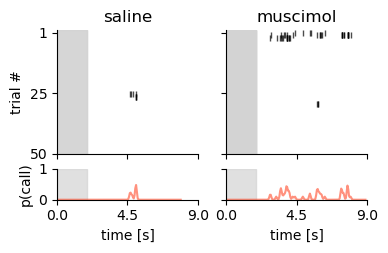

In [ ]:
n_trials = 50
bin_width = 0.05 # s
min_len = 0
        

stim_durs = {'distress_seq': 1.93, 'echo_seq': 1.33, 'isolation_1':0.37}

fig, axes = plt.subplots(
                         2, 2, gridspec_kw={'height_ratios': [4,1], 'hspace':0.2}, figsize=(4,2.2),
                        #  1, 2, figsize=(4,2),                         
                        sharey='row'
                        )
for i, treatment in enumerate(['saline', 'muscimol']):
    sess_n = i+3 # distress: +3 (3-4)
    seq = 'distress_seq'

    dat = anim_eg.loc[(anim_eg['sess_n']==sess_n) & 
                  (anim_eg['condition']==seq)].copy()
    max_len = np.ceil(np.max(np.diff(trial_struct_data[anim]['_'.join([str(sess_n),treatment])][seq]['trig_times'])))


    for i_trial in dat['trial_n'].unique():
        ax = axes[0,i]
        # ax = axes[i]

        irows = dat['trial_n']==i_trial
        onsets_in_trial = np.array(dat['start_seconds_trig'].loc[irows])
        offsets_in_trial = np.array(dat['stop_seconds_trig'].loc[irows])
        ax.plot(onsets_in_trial, np.ones_like(onsets_in_trial)*i_trial, marker='|', mew=1, markersize=4, ls="", c='k', alpha = 0.7)

        # gray out 
        ax.axvspan(0, stim_durs[seq], color = "lightgray", alpha = 0.7)
        ax.set_xlabel("time [s]")
        ax.set_xlim(min_len, max_len)

        ax.set_ylim([0, n_trials-1])
        ax.set_ylabel("trial #")   
        ax.set_yticks(np.linspace(1,n_trials,3),np.array(np.linspace(1,n_trials,3),dtype=int))
        ax.invert_yaxis()

        ax.set_title(treatment)

    # PLOT DENSITY? 
    ax = axes[1,i]
    bins = np.arange(min_len, max_len, bin_width)
    psth_dat, psth_x = np.histogram(np.array(dat['start_seconds_trig']), bins = bins, density=True) # so don't need to normalize for trials                                        
    psth_dat_norm = psth_dat/np.max(psth_dat) #/(n_trials) /bin_width
    gauss_1 = gaussian_filter1d(psth_dat_norm, sigma=1)

    # ax.bar(np.arange(min_len, max_len, bin_width)[0:-1], psth_dat_norm, width=bin_width, alpha = 0.9, color='k')
    ax.plot(np.arange(min_len, max_len, bin_width)[0:-1], gauss_1, color="tomato", alpha = 0.7)

    ax.axvspan(0, stim_durs[seq], color = "lightgray", alpha = 0.7)
    ax.set_xlim(min_len, max_len)
    ax.set_ylim(0,1)
    # ax.set_yticks([0, np.round(np.max(gauss_1),2)],[0,np.round(np.max(gauss_1),1)])
    ax.set_ylabel("p(call)")    
        

for ax in axes.flatten():
    ax.set_xlabel('time [s]')
    ax.set_xticks(np.linspace(min_len,max_len,3,endpoint=True))
    ax.spines[['right','top']].set_visible(False)
    ax.label_outer()
fig.tight_layout()
# fig.suptitle(condition_labels[seq], y=1.05)
for ext in ['.png','.pdf']:
    fig.savefig('/_example_trialresps_' + anim + '_sess'+str(sess_n-1)+'-'+str(sess_n) + seq + ext, 
                transparent=True, bbox_inches='tight', dpi=300)
